In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [ ]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [ ]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

# Pre-Processing

In [ ]:
# STEP 4: Check Missing Values

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [ ]:
# STEP 5: Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [ ]:
# Separate categorical and numerical columns

categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

# Fill categorical missing values
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical missing values
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Check remaining missing values

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [ ]:
# Convert categorical variables into numerical format

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0,1,3.0,2.0,0,4,4,2.0,3,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,2,0.0,0.0,0,5,2,1.0,4,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,2,2,5.0,21,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1,0,1.0,0.0,1,3,3,2.0,0,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,3,2,2.0,21,0


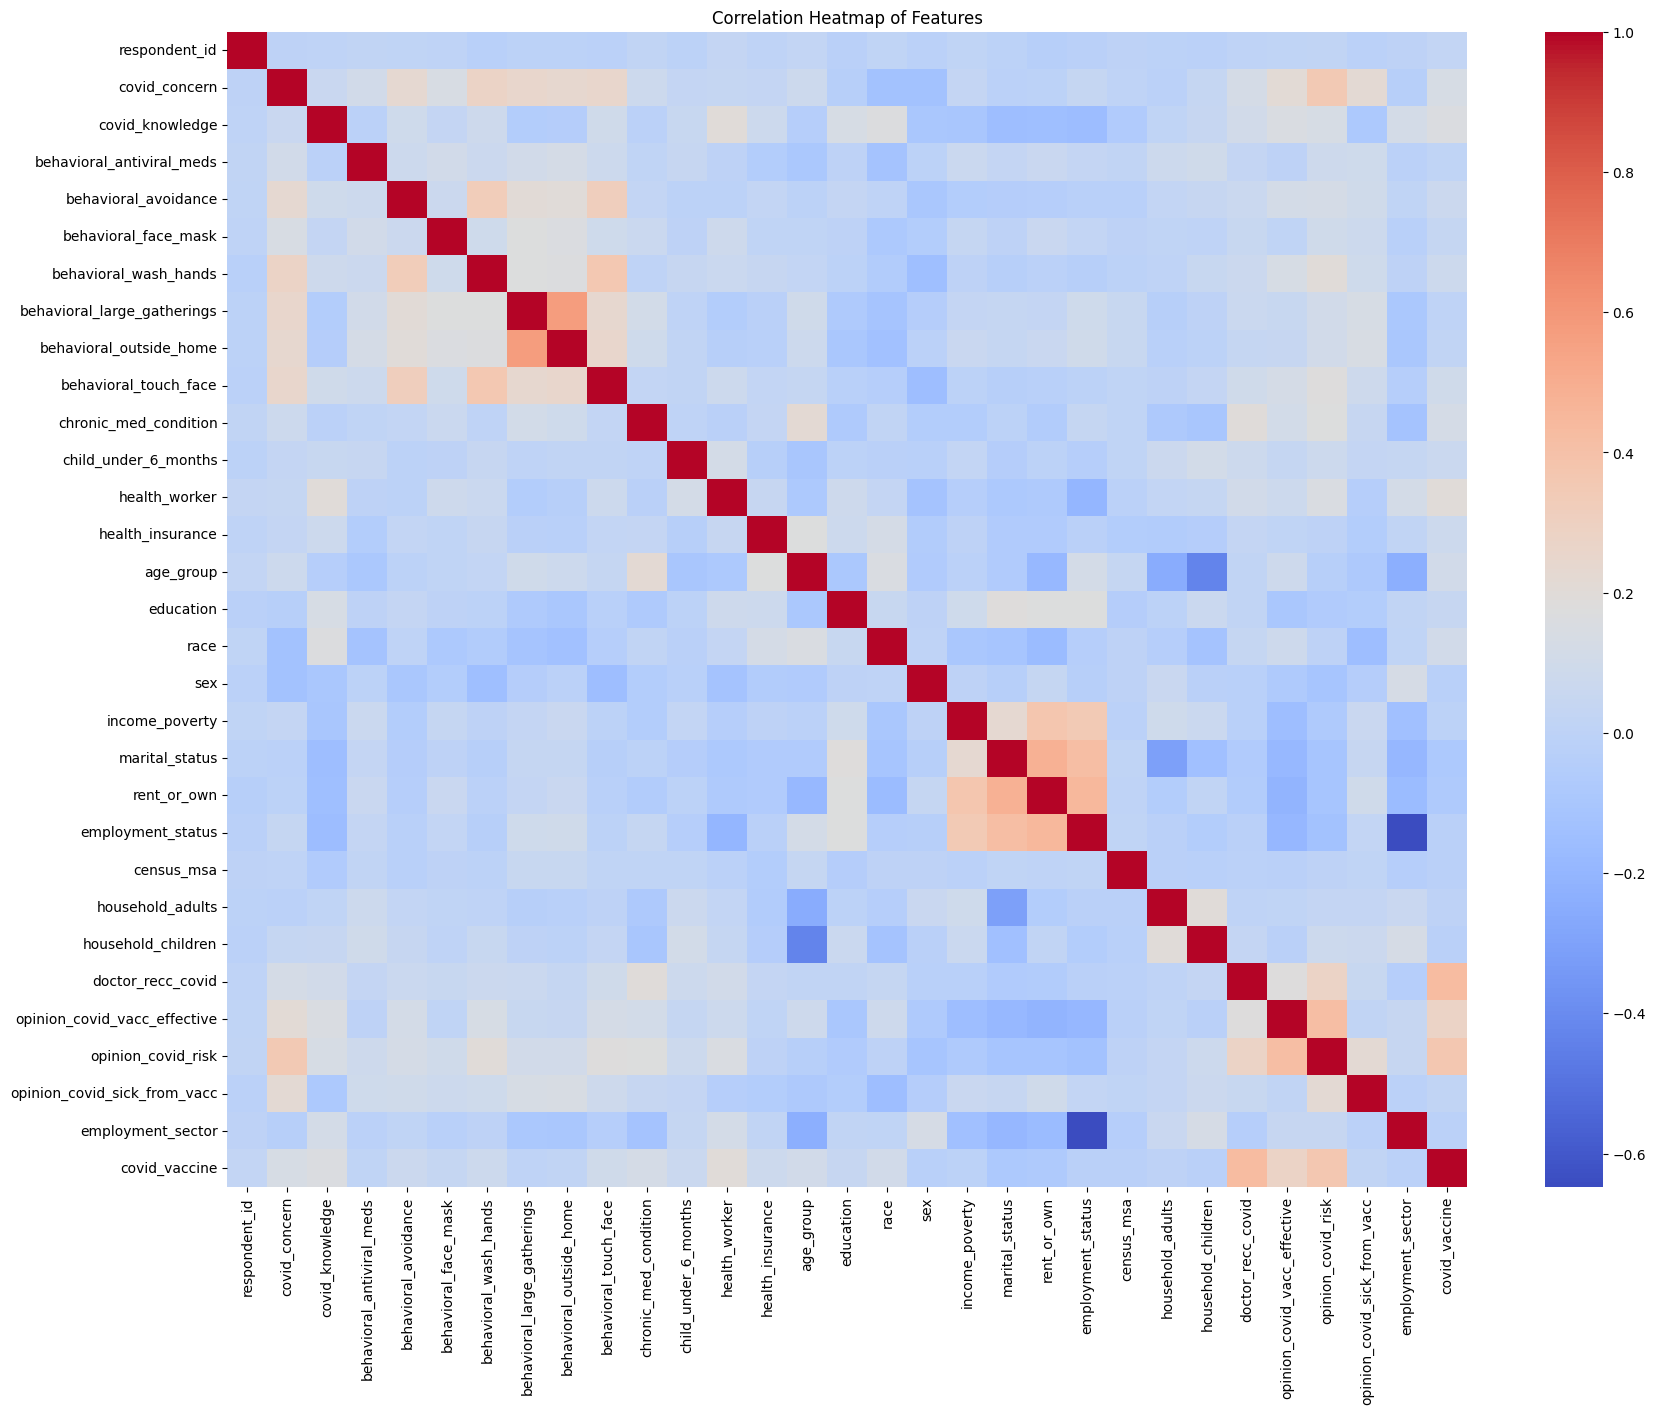

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
# Create feature matrix and target variable

X = df.drop("covid_vaccine", axis=1)
y = df["covid_vaccine"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4756, 30)
Target Shape: (4756,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3804, 30)
Testing Set: (952, 30)


# AutoML

In [ ]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpii333xx6
  JVM stdout: /tmp/tmpii333xx6/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpii333xx6/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 4 hours and 13 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_3iim21
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_grid_1_AutoML_1_20260605_135637_model_11,0.824079,0.478479,0.712853,0.247067,0.393571,0.154898,839,0.028931,XGBoost
XGBoost_3_AutoML_1_20260605_135637,0.822249,0.484559,0.707125,0.245293,0.395901,0.156737,1069,0.013728,XGBoost
XGBoost_grid_1_AutoML_1_20260605_135637_model_9,0.820466,0.480741,0.717605,0.249881,0.393914,0.155168,550,0.011725,XGBoost
GLM_1_AutoML_1_20260605_135637,0.819916,0.482103,0.730182,0.242861,0.392933,0.154396,574,0.012391,GLM
XGBoost_grid_1_AutoML_1_20260605_135637_model_7,0.817438,0.488183,0.708289,0.253361,0.397865,0.158297,562,0.013246,XGBoost
XGBoost_grid_1_AutoML_1_20260605_135637_model_3,0.814311,0.497858,0.696113,0.260484,0.399424,0.15954,692,0.011906,XGBoost
XGBoost_grid_1_AutoML_1_20260605_135637_model_5,0.813842,0.49666,0.695346,0.250935,0.399096,0.159277,909,0.01279,XGBoost
XGBoost_1_AutoML_1_20260605_135637,0.813556,0.49264,0.712306,0.259314,0.3988,0.159042,1237,0.012097,XGBoost
XGBoost_grid_1_AutoML_1_20260605_135637_model_4,0.812788,0.501536,0.697195,0.263623,0.40053,0.160424,682,0.01322,XGBoost
XGBoost_grid_1_AutoML_1_20260605_135637_model_2,0.812078,0.498766,0.694216,0.255064,0.401376,0.161102,629,0.016462,XGBoost


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

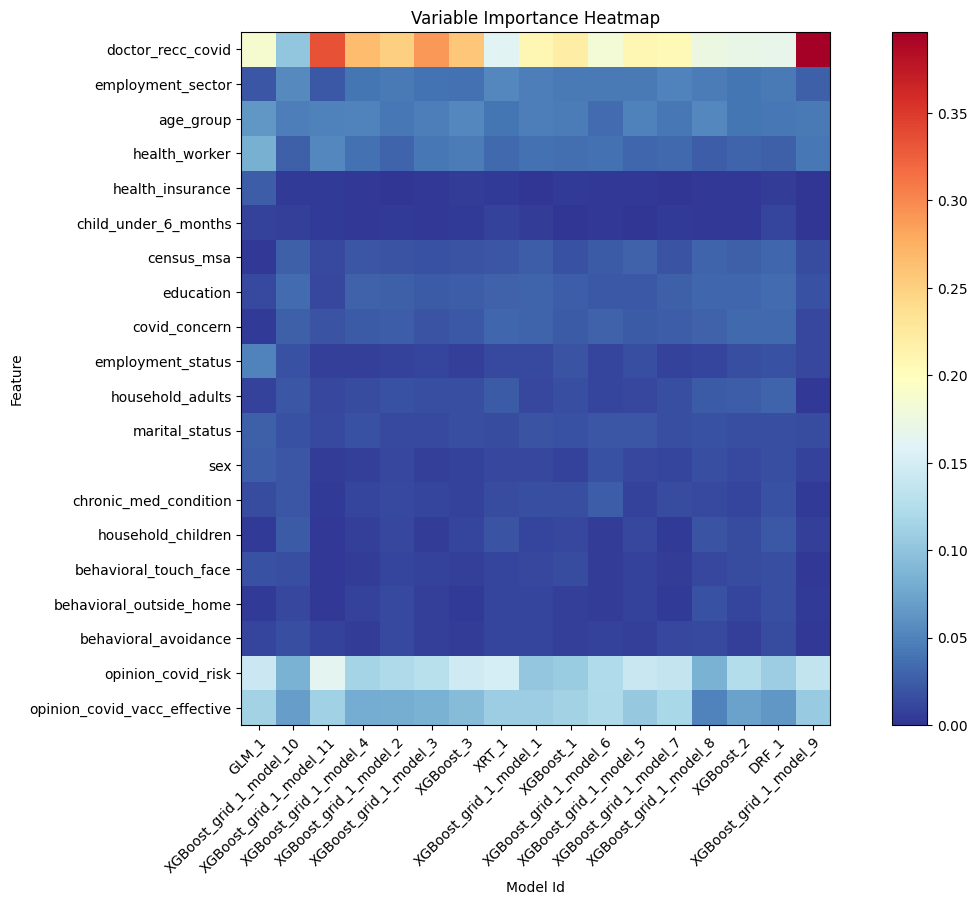

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

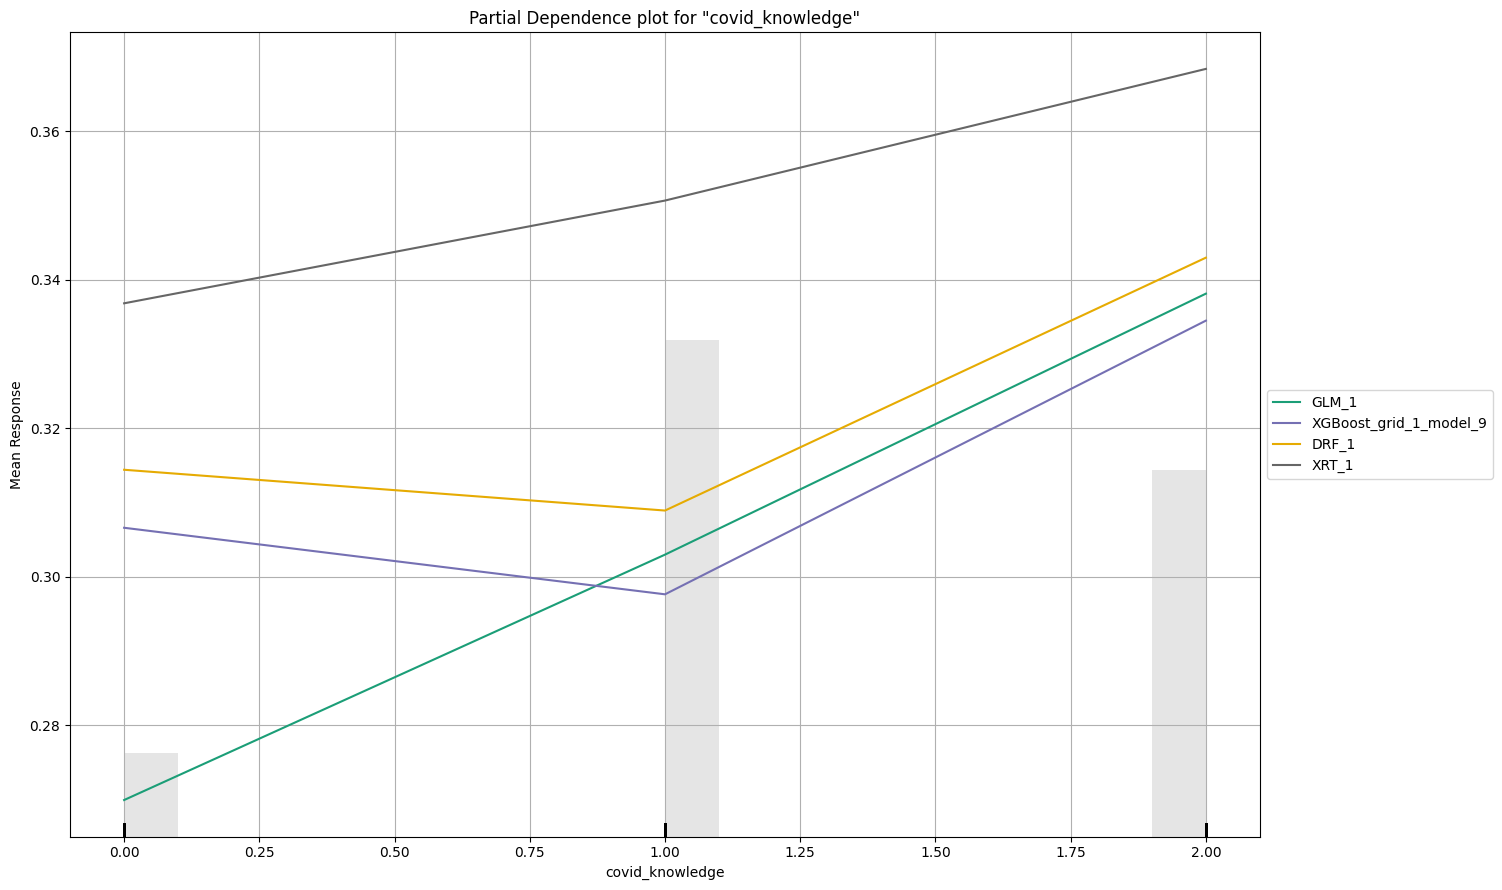

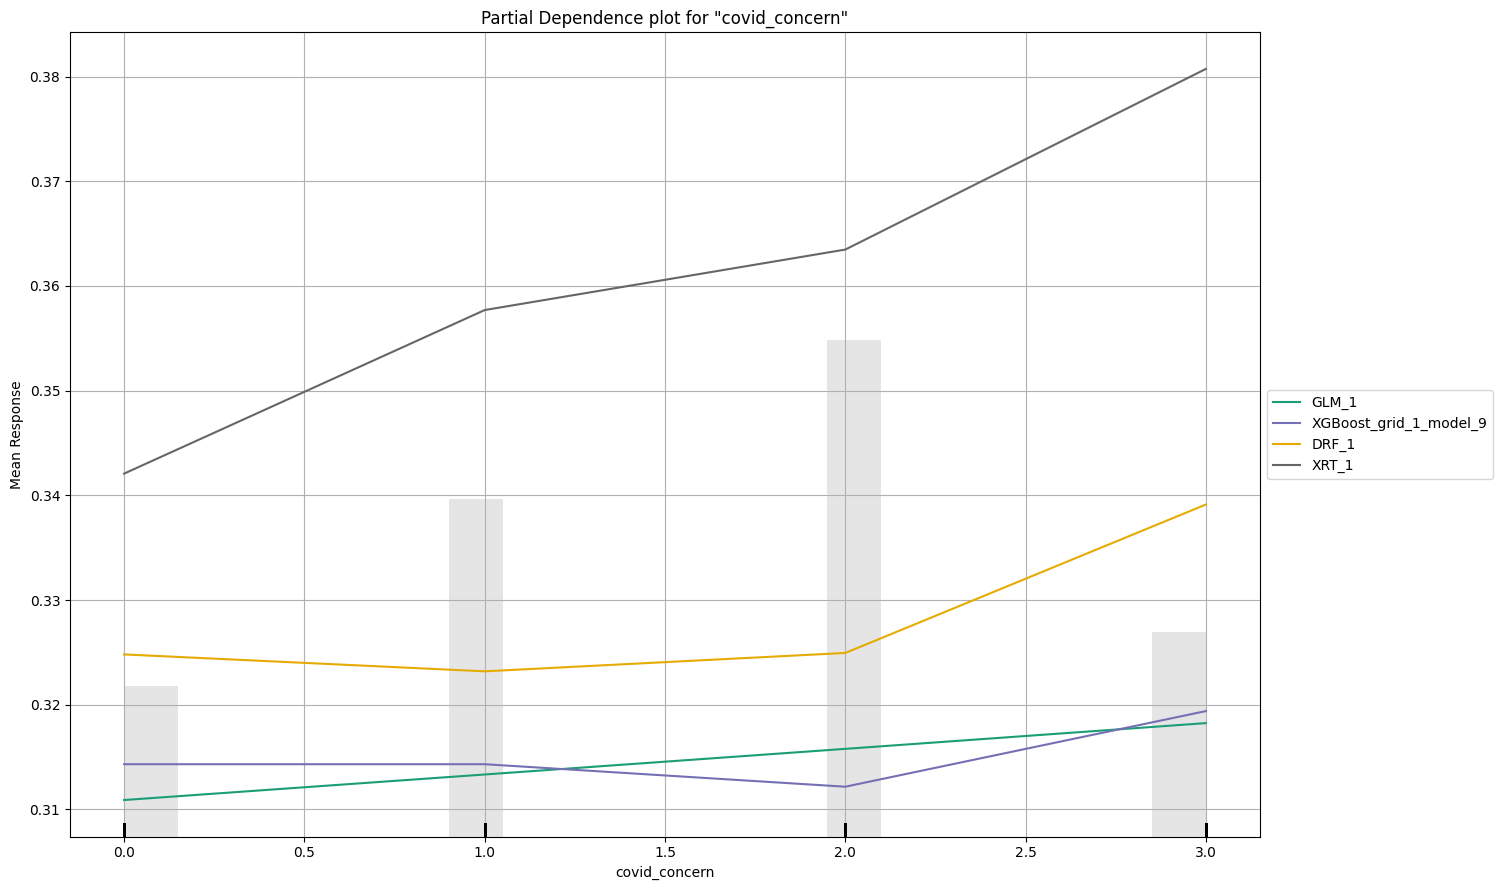

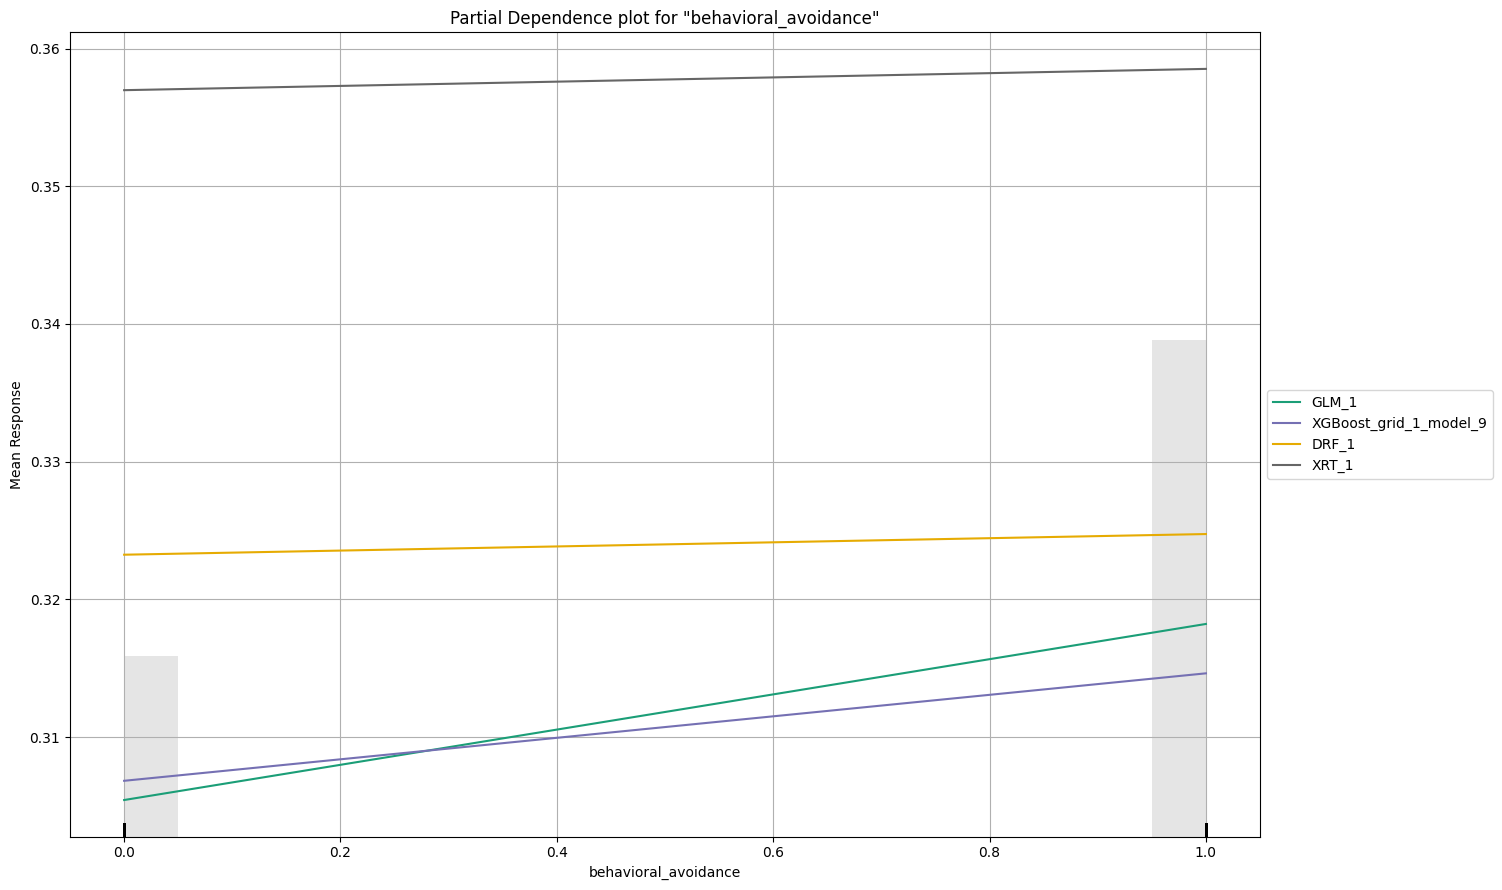

In [ ]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [ ]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.919646,0.0803542
0,0.762165,0.237835
0,0.907616,0.0923841
0,0.857999,0.142001
0,0.926802,0.073198
0,0.861965,0.138035
1,0.397016,0.602984
0,0.657949,0.342051
0,0.93457,0.0654299
0,0.85589,0.14411


In [ ]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.15439614730837398
RMSE: 0.3929327516361724
LogLoss: 0.48210312960859975
AUC: 0.8199163978460076
AUCPR: 0.7301818271007682
Gini: 0.6398327956920151
Null degrees of freedom: 1179
Residual degrees of freedom: 1149
Null deviance: 1509.6126773117362
Residual deviance: 1137.7633858762956
AIC: 1199.7633858762956

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.265719     0.677668  236
max f2                       0.200891     0.757238  274
max f0point5                 0.436315   

In [ ]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8199163978460076
F1 Score: [[0.2657194530003334, 0.6776677667766776]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)


# Data exploration

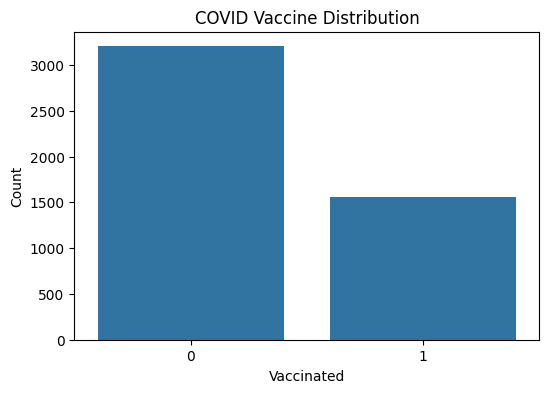

covid_vaccine
0    3202
1    1554
Name: count, dtype: int64


In [ ]:
# Distribution of target variable

plt.figure(figsize=(6,4))
sns.countplot(x='covid_vaccine', data=df)

plt.title('COVID Vaccine Distribution')
plt.xlabel('Vaccinated')
plt.ylabel('Count')
plt.show()

print(df['covid_vaccine'].value_counts())

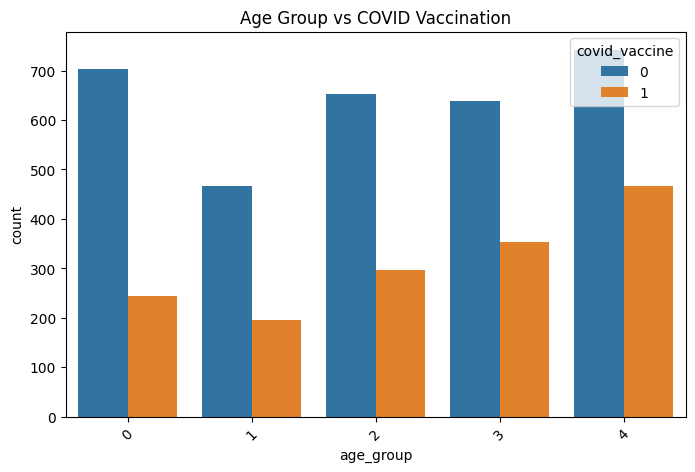

In [ ]:
# Age group and vaccination

plt.figure(figsize=(8,5))
sns.countplot(x='age_group', hue='covid_vaccine', data=df)

plt.title('Age Group vs COVID Vaccination')
plt.xticks(rotation=45)
plt.show()

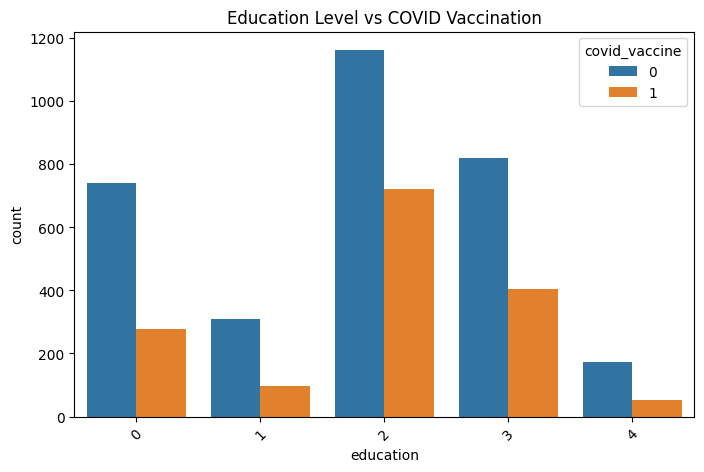

In [ ]:
# Education and vaccination

plt.figure(figsize=(8,5))
sns.countplot(x='education', hue='covid_vaccine', data=df)

plt.title('Education Level vs COVID Vaccination')
plt.xticks(rotation=45)
plt.show()

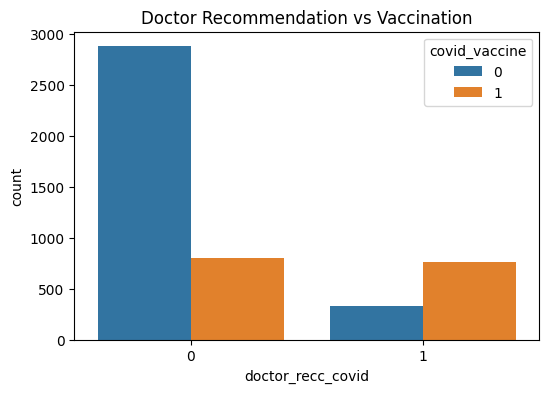

In [ ]:
# Doctor recommendation effect

plt.figure(figsize=(6,4))
sns.countplot(x='doctor_recc_covid', hue='covid_vaccine', data=df)

plt.title('Doctor Recommendation vs Vaccination')
plt.show()

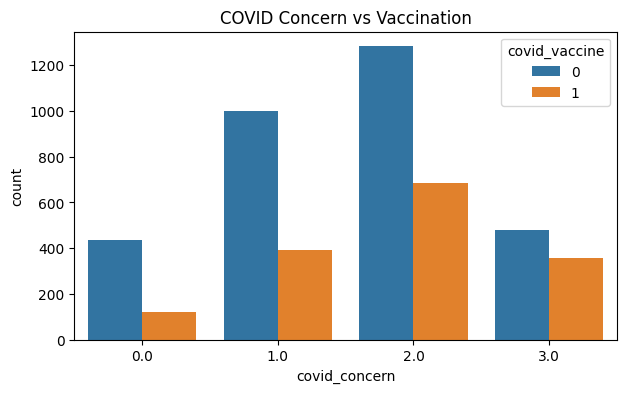

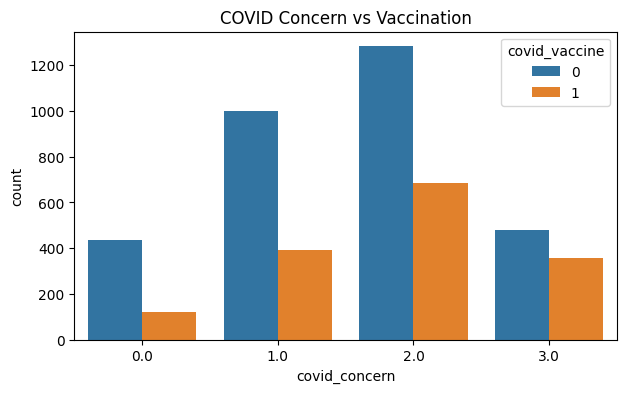

In [ ]:
# Concern level and vaccination

plt.figure(figsize=(7,4))
sns.countplot(x='covid_concern', hue='covid_vaccine', data=df)

plt.title('COVID Concern vs Vaccination')
plt.show()# Concern level and vaccination

plt.figure(figsize=(7,4))
sns.countplot(x='covid_concern', hue='covid_vaccine', data=df)

plt.title('COVID Concern vs Vaccination')
plt.show()

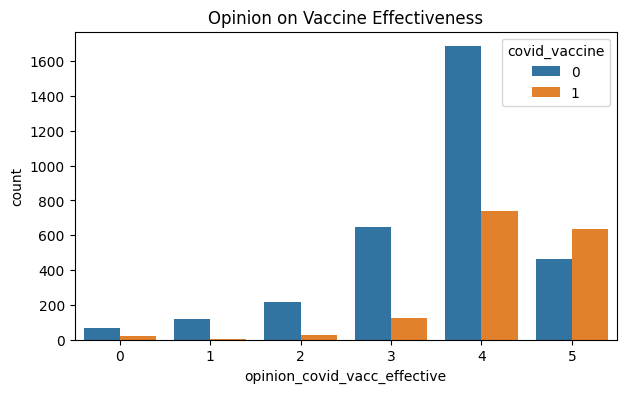

In [ ]:
# Vaccine effectiveness perception

plt.figure(figsize=(7,4))
sns.countplot(
    x='opinion_covid_vacc_effective',
    hue='covid_vaccine',
    data=df
)

plt.title('Opinion on Vaccine Effectiveness')
plt.show()

# Modelling (XGBOOST)

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Default XGBoost Model

xgb_default = XGBClassifier(
    random_state=42
)

xgb_default.fit(X_train, y_train)

# Predictions

y_pred_default = xgb_default.predict(X_test)
y_prob_default = xgb_default.predict_proba(X_test)[:,1]

In [ ]:
accuracy_default = accuracy_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)
roc_default = roc_auc_score(y_test, y_prob_default)

print("Accuracy :", accuracy_default)
print("Precision:", precision_default)
print("Recall   :", recall_default)
print("F1 Score :", f1_default)
print("ROC-AUC  :", roc_default)

Accuracy : 0.7584033613445378
Precision: 0.6600790513833992
Recall   : 0.5369774919614148
F1 Score : 0.5921985815602837
ROC-AUC  : 0.7957823136076567


In [ ]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       641
           1       0.66      0.54      0.59       311

    accuracy                           0.76       952
   macro avg       0.73      0.70      0.71       952
weighted avg       0.75      0.76      0.75       952



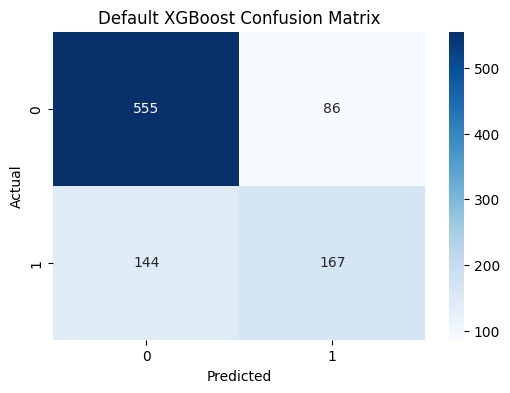

In [ ]:
cm = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Default XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:

# Load testing dataset
test_df = pd.read_csv("dataset_C_testing.csv")

# Store respondent IDs
test_ids = test_df["respondent_id"]

# Handle Missing Values

# Fill categorical columns
for col in categorical_columns:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna("Unknown")

# Fill numerical columns
for col in numerical_columns:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(df[col].median())


# Encode Categorical Variables
for col in categorical_columns:
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str)

# Re-fit encoder using combined data
for col in categorical_columns:

    combined = pd.concat([
        df[col].astype(str),
        test_df[col].astype(str)
    ])

    le = LabelEncoder()
    le.fit(combined)

    test_df[col] = le.transform(test_df[col].astype(str))


# Make Predictions
predictions = xgb_default.predict(test_df)


# Create Submission File
submission = pd.DataFrame({
    "respondent_id": test_ids,
    "covid_vaccine": predictions
})

submission.head()

,respondent_id,covid_vaccine
0,4757,0
1,4758,1
2,4759,0
3,4760,1
4,4761,0


In [46]:
submission.to_csv(
    "challange_submission_group_Q_order.csv",
    index=False
)

In [43]:
submission.shape

(4749, 2)

In [45]:
submission.head()

,respondent_id,covid_vaccine
0,4757,0
1,4758,1
2,4759,0
3,4760,1
4,4761,0


In [44]:
print("Default XGBoost Results")
print("Accuracy :", accuracy_default)
print("Precision:", precision_default)
print("Recall   :", recall_default)
print("F1 Score :", f1_default)
print("ROC-AUC  :", roc_default)

Default XGBoost Results
Accuracy : 0.7584033613445378
Precision: 0.6600790513833992
Recall   : 0.5369774919614148
F1 Score : 0.5921985815602837
ROC-AUC  : 0.7957823136076567
